IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
📊 در حال بارگذاری داده‌ها...
✅ 5000 رکورد بارگذاری شد.
⚠️ ستون fatalities حذف شد (جلوگیری از Target Leakage)

📈 داده آموزش: 4000 | داده آزمون: 1000

🌳 در حال آموزش مدل...
✅ مدل آموزش دید.

📊 Cross-Validation Accuracy: 0.7843 (+/- 0.0376)

📊 معیارهای عملکرد (داده آزمون):
🔹 Accuracy: 0.7930
🔹 Macro F1-Score: 0.6443

📋 گزارش طبقه‌بندی:
              precision    recall  f1-score   support

      Low(0)       0.97      0.83      0.90       678
      Med(1)       0.68      0.71      0.70       283
     High(2)       0.22      0.72      0.34        39

    accuracy                           0.79      1000
   macro avg       0.63      0.75      0.64      1000
weighted avg       0.86      0.79      0.82      1000



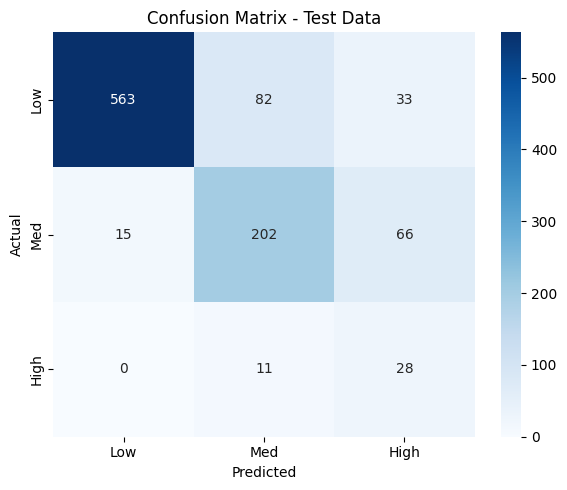


🔍 در حال محاسبه مقادیر SHAP...


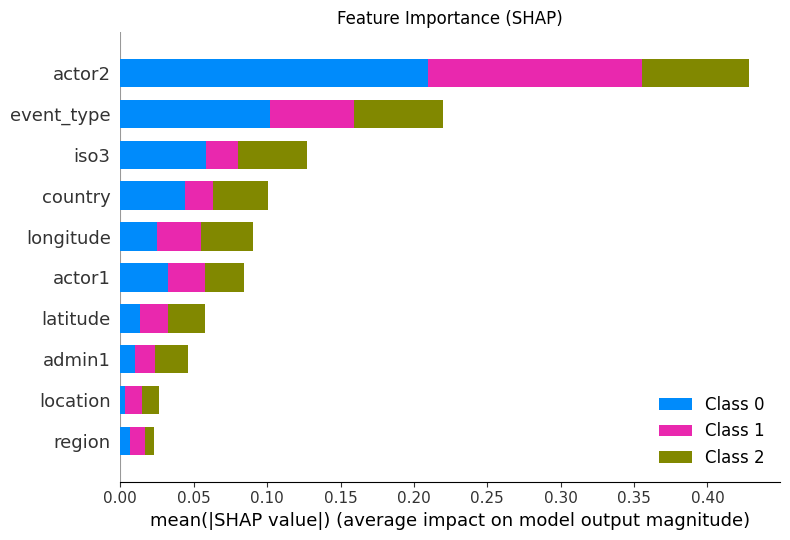

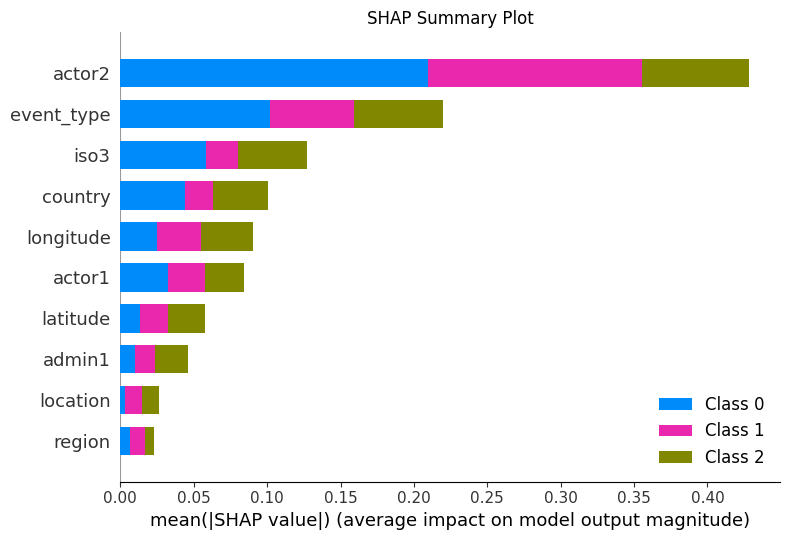


🔝  ویژگی برتر بر اساس SHAP:
1. actor2               : 0.1427
2. event_type           : 0.0733
3. iso3                 : 0.0423
4. country              : 0.0336
5. longitude            : 0.0302

✅ تمام شد! حالا نتایج واقع‌بینانه هستند.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import shap
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1️⃣ بارگذاری داده‌ها
# =========================================================
print("📊 در حال بارگذاری داده‌ها...")
df = pd.read_csv("ASIA5000.csv")
print(f"✅ {len(df)} رکورد بارگذاری شد.")

# =========================================================
# 2️⃣ حذف ستون‌هایی که باعث Target Leakage می‌شوند
# =========================================================
# ⚠️ fatalities مستقیماً در ساخت threat_level استفاده شده!
# باید حذف شود تا مدل واقع‌بینانه باشد
X = df.drop(['threat_level', 'fatalities'], axis=1)  # حذف fatalities
y = df['threat_level']

print("⚠️ ستون fatalities حذف شد (جلوگیری از Target Leakage)")

# =========================================================
# 3️⃣ کدگذاری متغیرهای دسته‌ای
# =========================================================
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = X[col].fillna('Unknown').astype(str)
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

X = X.fillna(0)

# =========================================================
# 4️⃣ تقسیم داده با SHUFFLE کامل (خیلی مهم!)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y,
    shuffle=True  # ✅ خیلی مهم: قاطی کردن داده‌ها
)

print(f"\n📈 داده آموزش: {len(X_train)} | داده آزمون: {len(X_test)}")

# =========================================================
# 5️⃣ آموزش مدل با پارامترهای محافظه‌کارانه‌تر
# =========================================================
print("\n🌳 در حال آموزش مدل...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,           # کاهش عمق برای جلوگیری از overfitting
    min_samples_split=10,  # افزایش حداقل نمونه برای split
    min_samples_leaf=5,    # افزایش حداقل نمونه در برگ
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("✅ مدل آموزش دید.")

# =========================================================
# 6️⃣ ارزیابی با Cross-Validation (معتبرتر)
# =========================================================
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n📊 Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# =========================================================
# 7️⃣ ارزیابی نهایی روی داده آزمون
# =========================================================
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("\n📊 معیارهای عملکرد (داده آزمون):")
print(f"🔹 Accuracy: {acc:.4f}")
print(f"🔹 Macro F1-Score: {f1_macro:.4f}")

print("\n📋 گزارش طبقه‌بندی:")
print(classification_report(y_test, y_pred, target_names=['Low(0)', 'Med(1)', 'High(2)']))

# ماتریس درهم‌ریختگی
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low','Med','High'], yticklabels=['Low','Med','High'])
plt.title('Confusion Matrix - Test Data')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("confusion_matrix_fixed.png", dpi=300)
plt.show()

# =========================================================
# 8️⃣ تحلیل SHAP
# =========================================================
print("\n🔍 در حال محاسبه مقادیر SHAP...")

# برای سرعت بیشتر، از نمونه کوچکتری استفاده کن
if len(X_test) > 2000:
    X_sample = X_test.sample(n=2000, random_state=42)
    y_sample = y_test.loc[X_sample.index]
    print(f"📊 نمونه‌برداری: {len(X_sample)} رکورد برای SHAP")
else:
    X_sample = X_test
    y_sample = y_test

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

# نمودار میله‌ای
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False, max_display=10)
plt.title("Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_bar_fixed.png", dpi=300)
plt.show()

# نمودار Summary
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False, max_display=10)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("shap_summary_fixed.png", dpi=300)
plt.show()

# 🔢 استخراج مقادیر عددی
print("\n🔝  ویژگی برتر بر اساس SHAP:")
print("="*50)

if isinstance(shap_values, list):
    mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

feature_importance = sorted(zip(X.columns, mean_shap), key=lambda x: x[1], reverse=True)
for i, (feat, val) in enumerate(feature_importance[:5], 1):
    print(f"{i}. {feat:<20} : {val:.4f}")

print("\n✅ تمام شد! حالا نتایج واقع‌بینانه هستند.")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=03a28703-528a-4cbd-9095-b00e0397c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>